This notebook requires ``processed_data.csv``. To generate it follow the steps ``01-03``.

In [62]:
import pandas as pd

df = pd.read_csv('data/processed_data.csv')
df.head()

C:\Users\l\AppData\Local\Temp\ipykernel_73932\4123914190.py:3: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed_data.csv')


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,day_of_week,month,is_weekend,season,date,temp,precipitation,rain,cloudcover,windspeed
0,4C1563485B2BC1B5,classic_bike,2021-01-01 13:02:20.043,2021-01-01 13:06:54.252,Willis Ave & E 141 St,7759.08,Morris Ave & E 142 St,7821.01,40.810930,-73.921606,...,Friday,January,False,Winter,2021-01-01,0.729167,1.0,1.0,48.416667,7.6125
1,4C1563485B2BC1B5,classic_bike,2021-01-01 13:02:20.043,2021-01-01 13:06:54.252,Willis Ave & E 141 St,7759.08,Morris Ave & E 142 St,7821.01,40.810930,-73.921606,...,Friday,January,False,Winter,2021-01-01,0.729167,1.0,1.0,48.416667,7.6125
2,6FB71DDD88A98375,electric_bike,2021-01-01 12:51:05.140,2021-01-01 13:08:58.948,S 4 St & Wythe Ave,5204.05,Grand Army Plaza & Plaza St West,4010.15,40.712859,-73.965903,...,Friday,January,False,Winter,2021-01-01,0.729167,1.0,1.0,48.416667,7.6125
3,6FB71DDD88A98375,electric_bike,2021-01-01 12:51:05.140,2021-01-01 13:08:58.948,S 4 St & Wythe Ave,5204.05,Grand Army Plaza & Plaza St West,4010.15,40.712859,-73.965903,...,Friday,January,False,Winter,2021-01-01,0.729167,1.0,1.0,48.416667,7.6125
4,37C923C6A52E6886,electric_bike,2021-01-26 20:39:37.656,2021-01-26 20:42:27.453,E 51 St & 1 Ave,6532.06,E 56 St & 3 Ave,6691.11,40.754557,-73.965930,...,Tuesday,January,False,Winter,2021-01-26,-0.029167,5.2,1.5,76.166667,9.8375


# Data Visualizaiton

### Hourly Bike Damnd

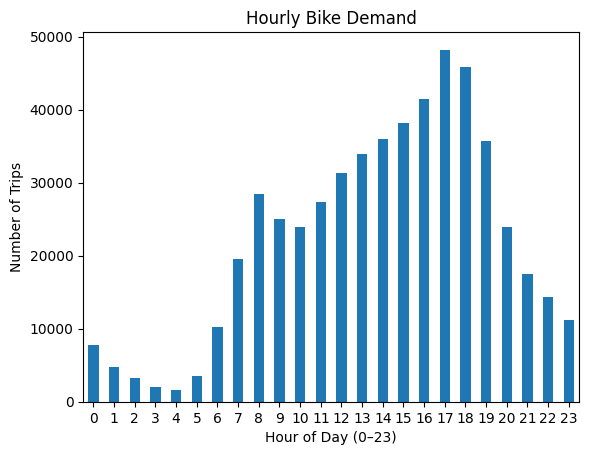

In [63]:
import matplotlib.pyplot as plt

plt.figure()

hourly_counts = df.groupby('hour').size()

hourly_counts.sort_index().plot(kind='bar')

plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Trips")
plt.title("Hourly Bike Demand")
plt.xticks(rotation=0)

plt.show()




### Most Popular Start/End Stations

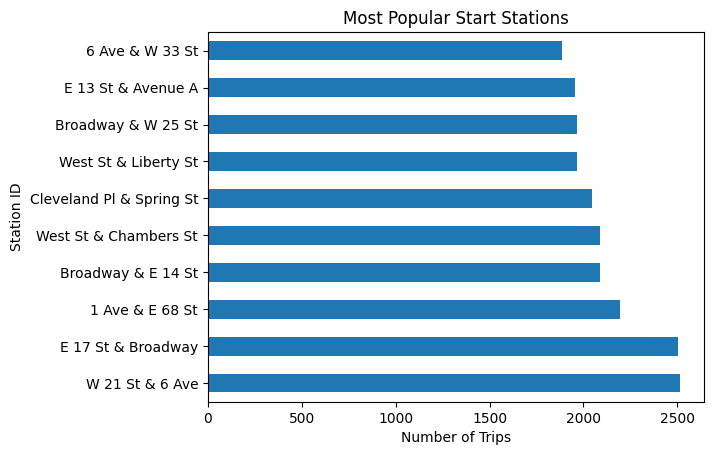

In [64]:
most_popular_stations = df.groupby('start_station_name').size().nlargest(10)

most_popular_stations.plot(kind='barh')
plt.ylabel("Station ID")
plt.xlabel("Number of Trips")
plt.title("Most Popular Start Stations")

plt.show()

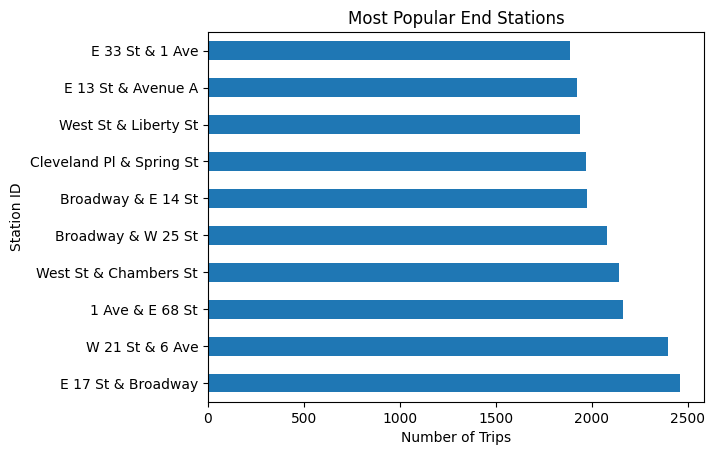

In [65]:
most_popular_stations = df.groupby('end_station_name').size().nlargest(10)

most_popular_stations.plot(kind='barh')
plt.ylabel("Station ID")
plt.xlabel("Number of Trips")
plt.title("Most Popular End Stations")

plt.show()

### What are the most popular trips?

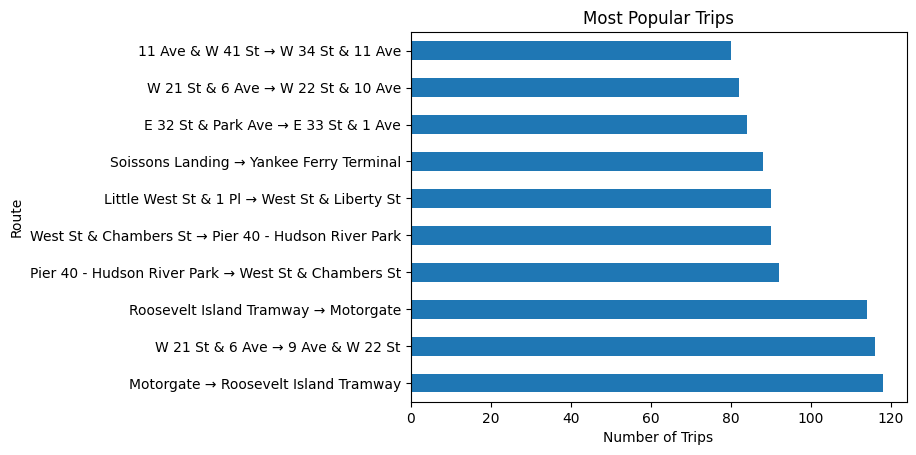

In [66]:
df_filtered = df[df['start_station_name'] != df['end_station_name']]

df_filtered['route'] = df_filtered['start_station_name'] + " → " + df_filtered['end_station_name']
top_routes = df_filtered['route'].value_counts().head(10)

top_routes.plot(kind='barh')
plt.ylabel("Route")
plt.xlabel("Number of Trips")
plt.title("Most Popular Trips")

plt.show()

### On Average, how long does a trip take?

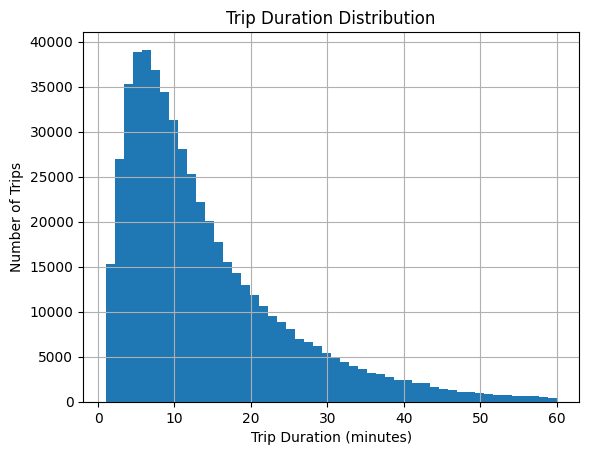

In [67]:
# Trip Duration Distribution

plt.figure()

df_filtered = df[
    (df['trip_duration_min'] > 1) & 
    (df['trip_duration_min'] < 60)
]
df_filtered['trip_duration_min'].hist(bins=50)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.title("Trip Duration Distribution")

plt.show()

### When are the peak hours, and the difference between weekdays and weekends

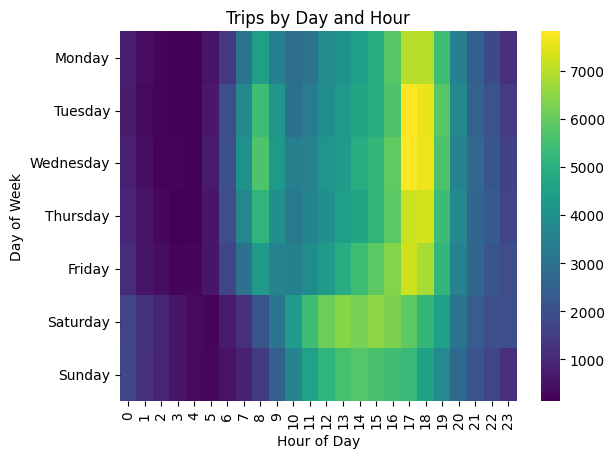

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack()
heatmap_data = heatmap_data.reindex(days_of_week)

plt.figure()
sns.heatmap(heatmap_data, cmap='viridis')

plt.title("Trips by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

### How does the weather affect the bike usage?

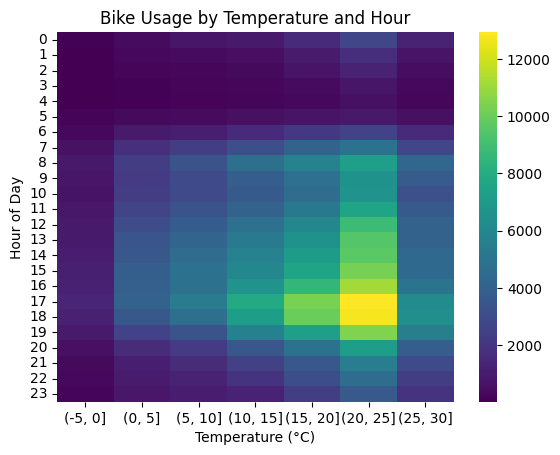

In [69]:
df['tempbin'] = pd.cut(df['temp'], bins=[-5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 50])
heatmap_data = df.groupby(['hour', 'tempbin']).size().unstack()

plt.figure()
sns.heatmap(heatmap_data, cmap='viridis')

plt.xlabel("Temperature (°C)")
plt.ylabel("Hour of Day")
plt.title("Bike Usage by Temperature and Hour")

plt.show()

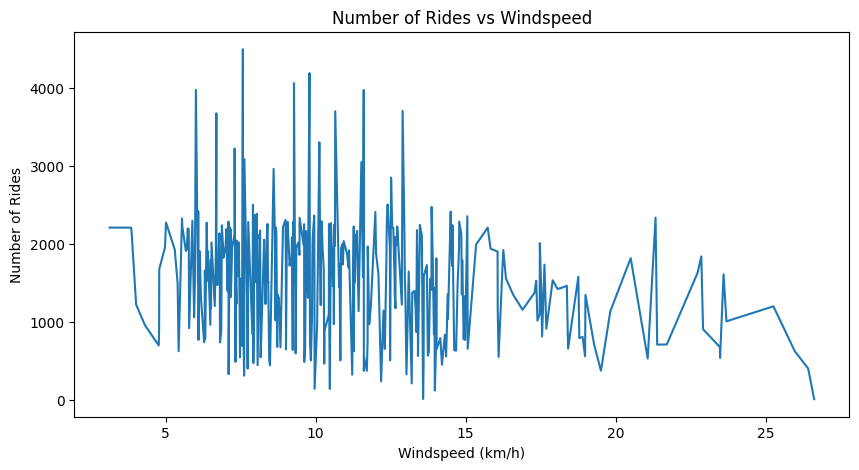

In [70]:
windspeed_usage = df.groupby('windspeed')['ride_id'].count().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(x='windspeed', y='ride_id', data=windspeed_usage)
plt.title("Number of Rides vs Windspeed")
plt.xlabel("Windspeed (km/h)")
plt.ylabel("Number of Rides")
plt.show()

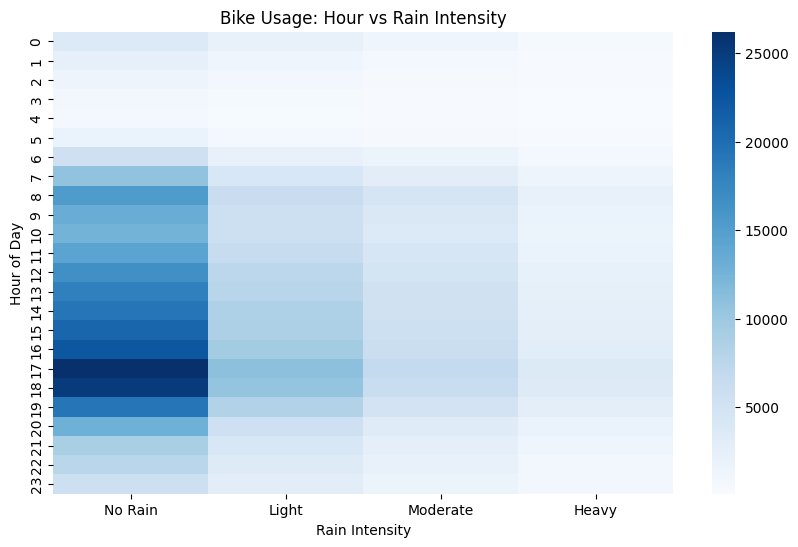

In [71]:

df['rain_bin'] = pd.cut(df['rain'], bins=[-0.1, 0, 2, 10, 50], labels=['No Rain','Light','Moderate','Heavy'])

heatmap_rain_bin = df.groupby(['hour','rain_bin']).size().unstack()
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_rain_bin, cmap='Blues', fmt='d')
plt.title("Bike Usage: Hour vs Rain Intensity")
plt.xlabel("Rain Intensity")
plt.ylabel("Hour of Day")
plt.show()

### Top 10 Stations usage heatmap

<Axes: title={'center': 'Bike Usage: Top 10 Stations'}, xlabel='hour', ylabel='start_station_name'>

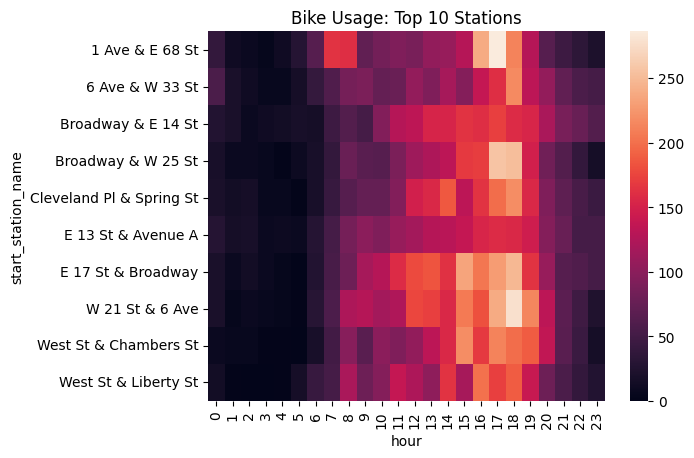

In [72]:
top_stations = df['start_station_name'].value_counts().head(10).index

filtered = df[df['start_station_name'].isin(top_stations)]

heatmap_data = filtered.groupby(['start_station_name', 'hour']).size().unstack().fillna(0)
plt.title("Bike Usage: Top 10 Stations")

sns.heatmap(heatmap_data)

### Geographic density of station usage

Hexbin plots show where trips **start** and **end** in geographic space (denser cells = more trips). Coordinates are sampled when the dataset is large so the notebook stays responsive.

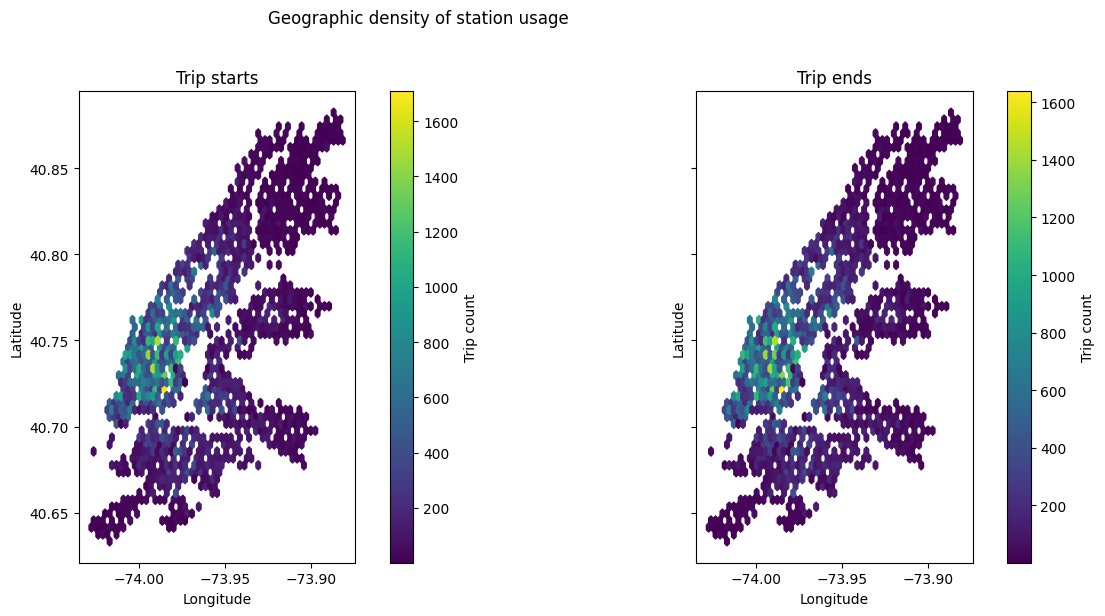

In [73]:
n = min(200_000, len(df))
geo = df[['start_lat', 'start_lng', 'end_lat', 'end_lng']].dropna()
sample = geo.sample(n=n, random_state=42) if len(geo) > n else geo

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
pairs = [
    (sample['start_lng'], sample['start_lat'], 'Trip starts'),
    (sample['end_lng'], sample['end_lat'], 'Trip ends'),
]
for ax, (lng_s, lat_s, title) in zip(axes, pairs):
    hb = ax.hexbin(lng_s, lat_s, gridsize=55, cmap='viridis', mincnt=1)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    plt.colorbar(hb, ax=ax, label='Trip count', fraction=0.046)

plt.suptitle('Geographic density of station usage', y=1.02)
plt.tight_layout()
plt.show()

## Casual vs Members Trends

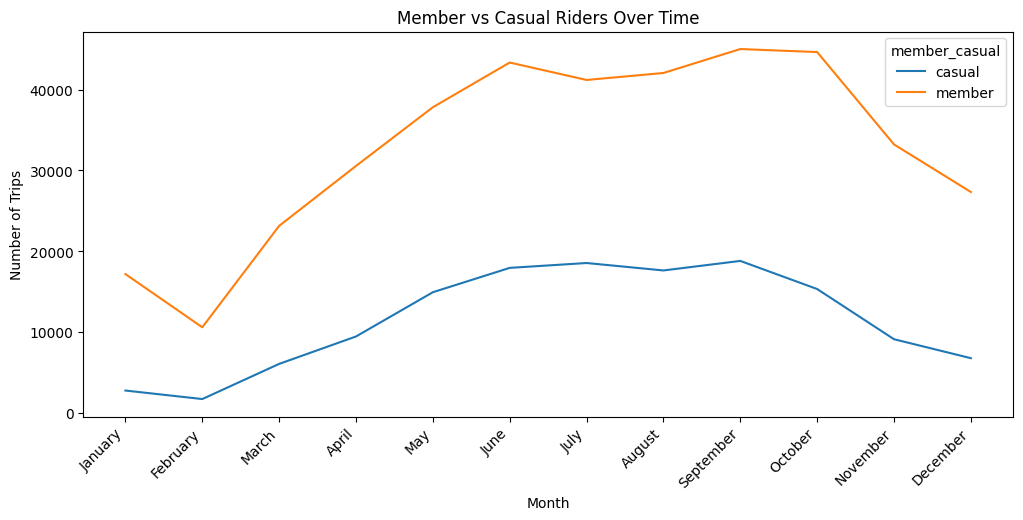

In [74]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
grouped = df.groupby(["month", "member_casual"]).size().unstack(fill_value=0)
# force all months to appear in this exact order
grouped = grouped.reindex(month_order, fill_value=0)
ax = grouped.plot(figsize=(12, 5))
ax.set_xticks(range(len(grouped.index)))
ax.set_xticklabels(grouped.index, rotation=45, ha="right")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.title("Member vs Casual Riders Over Time")
plt.show()

<Figure size 1000x600 with 0 Axes>

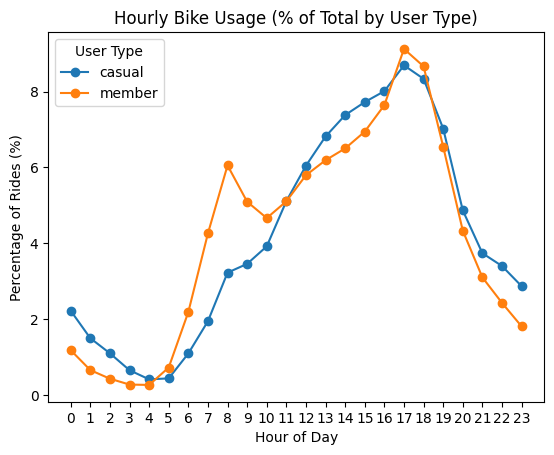

In [75]:
hourly_grouped = df.groupby(['hour', 'member_casual']).size().unstack()

hourly_percent = hourly_grouped.div(hourly_grouped.sum(axis=0), axis=1) * 100

plt.figure(figsize=(10,6))
hourly_percent.plot(marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Percentage of Rides (%)")
plt.title("Hourly Bike Usage (% of Total by User Type)")
plt.xticks(range(0,24))
plt.legend(title="User Type")
plt.show()

<Figure size 640x480 with 0 Axes>

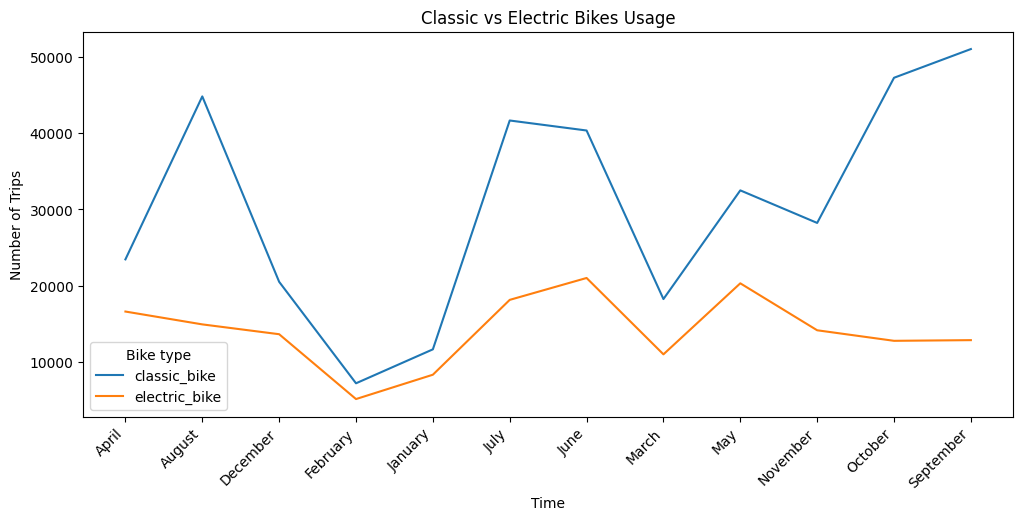

In [76]:
grouped = df.groupby(['month', 'rideable_type']).size().unstack()

plt.figure()

ax = grouped.plot(figsize=(12, 5))
ax.set_xticks(range(len(grouped.index)))
ax.set_xticklabels(grouped.index, rotation=45, ha="right")

plt.xlabel("Time")
plt.ylabel("Number of Trips")
plt.title("Classic vs Electric Bikes Usage")

plt.legend(title="Bike type")
plt.show()

In [77]:
# User-type behavior: trip duration distribution by user type
duration_user = df[['member_casual', 'trip_duration_min', 'season', 'day_of_week', "rideable_type"]].dropna().copy()
duration_user = duration_user[
    duration_user['trip_duration_min'].between(1, 60)
]

duration_user_sample = duration_user.sample(n=10000, random_state=42)


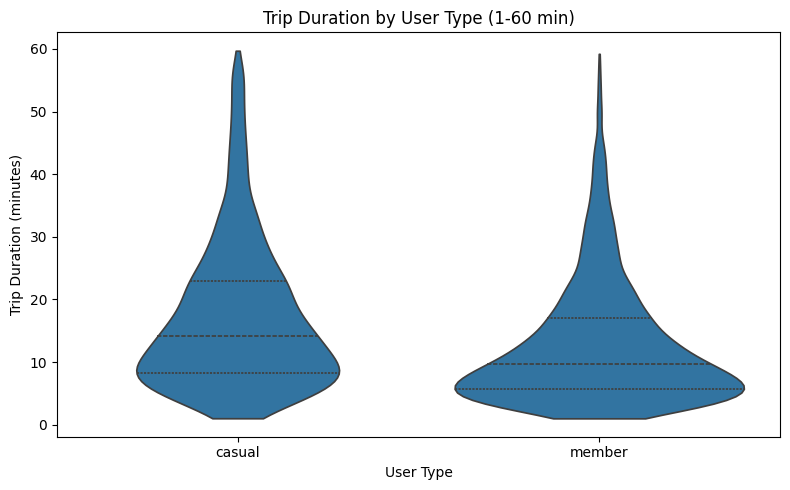

In [78]:

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=duration_user_sample,
    x='member_casual',
    y='trip_duration_min',
    inner='quartile',
    cut=0
)
plt.title('Trip Duration by User Type (1-60 min)')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.tight_layout()
plt.show()

C:\Users\l\AppData\Local\Temp\ipykernel_73932\1668467468.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


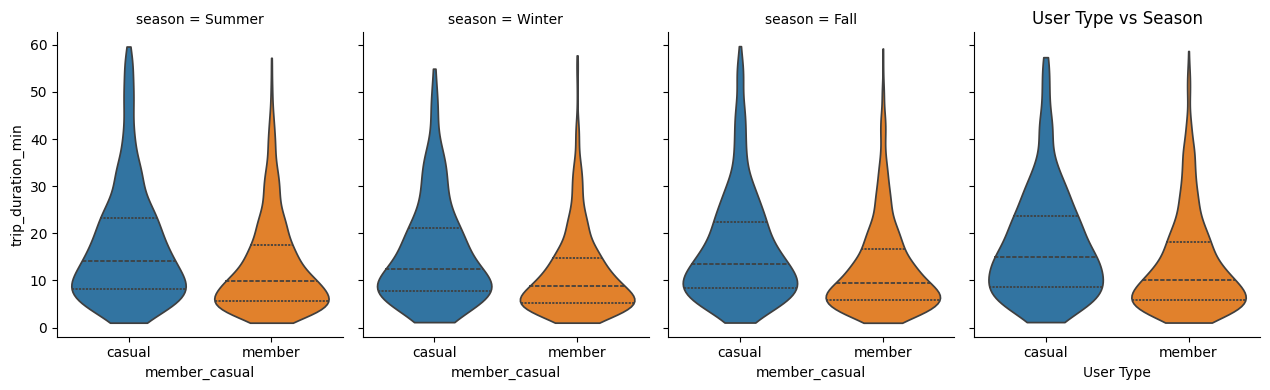

In [79]:
sns.catplot(
    data=duration_user_sample,
    x='member_casual',
    y='trip_duration_min',
    col='season',         # facet by season
    kind='violin',
    inner='quartile',
    cut=0,
    height=4,
    aspect=0.8,
    palette=['#1f77b4', '#ff7f0e']
)
plt.title('User Type vs Season')
plt.xlabel('User Type')
plt.ylabel('Season')
plt.tight_layout()
plt.show()

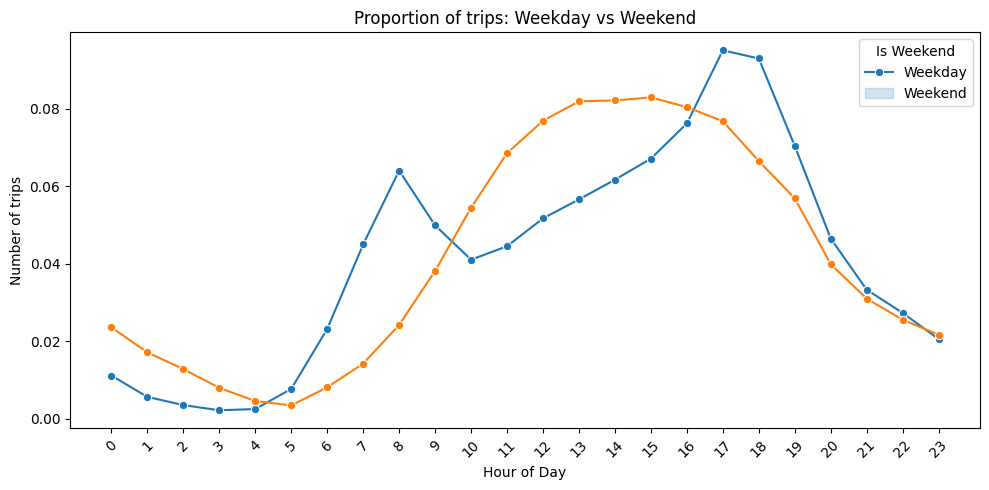

In [80]:
hourly_week = (
    df.groupby(['hour', 'is_weekend'])
    .size()
    .reset_index(name='trips')
)

hourly_week['normalized'] = (
    hourly_week.groupby('is_weekend')['trips']
    .transform(lambda x: x / x.sum())
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly_week,
    x='hour',
    y='normalized',
    hue='is_weekend',
    marker='o'
)
plt.title('Proportion of trips: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Number of trips')
plt.xticks(range(0, 24, 1), rotation=45)
plt.legend(title='Is Weekend', labels=['Weekday', 'Weekend'])
plt.tight_layout()
plt.show()